# 1. Geometría y Optimización (Condicionales)  

Un problema común en ciencia de datos es la clasificación por cercanía. Dado un punto fijo $C = (h, k)$ que representa el centro de una región, y un punto de datos $P = (x, y)$:  

1.	Solicite al usuario las coordenadas de C y de P.
2.	Calcule la distancia euclidiana al cuadrado: $D2 = (x - h)^2 + (y - k)^2$.
3.	Use condicionales para clasificar el punto:
o	Si D2 < 25: "Región de Alta Densidad".
o	Si 25 <= D2 <= 100: "Región Periférica".
o	Si D2 > 100: "Dato Atípico (Outlier)".


Este es un problema clásico de clasificación basado en métricas de distancia. 

Para resolverlo, utilizaremos la **distancia euclidiana al cuadrado**, que es una medida muy eficiente en computación ya que evita el cálculo de la raíz cuadrada, manteniendo la proporcionalidad de las distancias.

Aquí tienes el código completo que solicita los datos, clasifica el punto y genera la visualización utilizando `matplotlib` y `seaborn`.



## Solución en Python


--- Clasificador de Cercanía ---

Resultado: D^2 = 2.00
Clasificación: Región de Alta Densidad


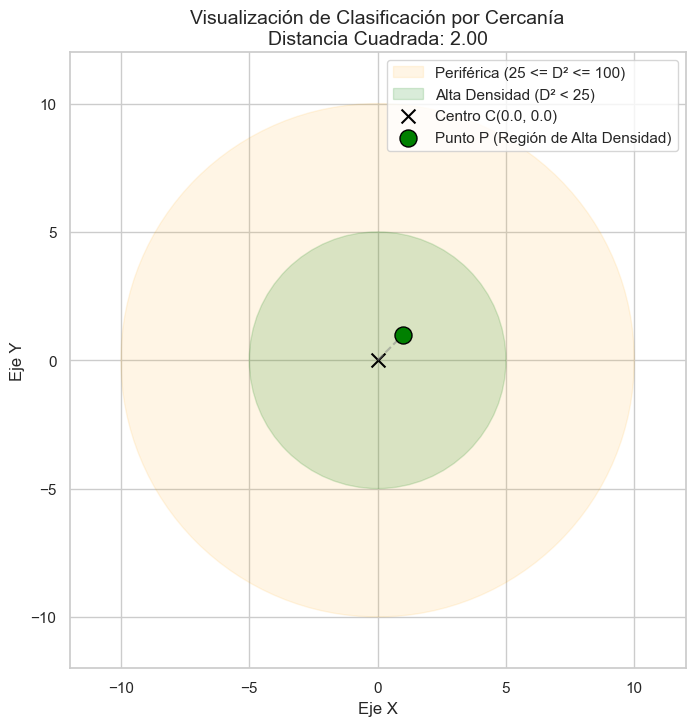

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Entrada de datos
print("--- Clasificador de Cercanía ---")
h = float(input("Ingrese coordenada h del centro C: "))
k = float(input("Ingrese coordenada k del centro C: "))
x = float(input("Ingrese coordenada x del punto P: "))
y = float(input("Ingrese coordenada y del punto P: "))

# 2. Cálculo de la Distancia Euclidiana al Cuadrado
# Formula: D^2 = (x - h)^2 + (y - k)^2
distancia_sq = (x - h)**2 + (y - k)**2

# 3. Clasificación con condicionales
if distancia_sq < 25:
    clasificacion = "Región de Alta Densidad"
    color = "green"
elif 25 <= distancia_sq <= 100:
    clasificacion = "Región Periférica"
    color = "orange"
else:
    clasificacion = "Dato Atípico (Outlier)"
    color = "red"

print(f"\nResultado: D^2 = {distancia_sq:.2f}")
print(f"Clasificación: {clasificacion}")

# 4. Representación Visual
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 8))

# Dibujamos las regiones (círculos de radio 5 y 10, ya que 5^2=25 y 10^2=100)
circulo_alta = plt.Circle((h, k), 5, color='green', alpha=0.15, label='Alta Densidad (D² < 25)')
circulo_perif = plt.Circle((h, k), 10, color='orange', alpha=0.1, label='Periférica (25 <= D² <= 100)')
ax.add_patch(circulo_perif)
ax.add_patch(circulo_alta)

# Graficar puntos
plt.scatter(h, k, color='black', marker='x', s=100, label=f'Centro C({h}, {k})')
plt.scatter(x, y, color=color, s=150, edgecolors='black', zorder=5, label=f'Punto P ({clasificacion})')

# Línea de distancia
plt.plot([h, x], [k, y], linestyle='--', color='gray', alpha=0.5)

# Configuración de límites y estética
limite = max(12, abs(x-h)+2, abs(y-k)+2)
ax.set_xlim(h - limite, h + limite)
ax.set_ylim(k - limite, k + limite)
ax.set_aspect('equal')
plt.title(f"Visualización de Clasificación por Cercanía\nDistancia Cuadrada: {distancia_sq:.2f}", fontsize=14)
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.legend(loc='upper right')
plt.savefig(r"C:\Users\marco\Downloads\clasificador_cercania.png", dpi=300)
plt.show()


# Explicación de la Lógica

1.  **El Centro $C$:** Actúa como el origen de nuestro sistema de referencia local.
2.  **Las Regiones:** * La **Región de Alta Densidad** está definida por un radio $r < 5$, porque $5^2 = 25$.
    * La **Región Periférica** está definida por un radio entre $5$ y $10$, porque $10^2 = 100$.
    * Cualquier punto fuera de radio $10$ se considera **Outlier**.


3.  **Visualización:** He utilizado círculos concéntricos para que puedas ver exactamente en qué "zona" cae tu punto $P$. El color del punto en la gráfica cambiará automáticamente según la clasificación obtenida.

# Segundo punto del parcial 2_7   

Este es un excelente ejercicio para entender cómo los algoritmos numéricos "acorralan" un valor real. El método de bisección se basa en el **Teorema del Valor Intermedio**, asegurando que si una función continua cambia de signo en un intervalo, existe al menos una raíz allí.

Aquí tienes el código que implementa las 10 iteraciones y genera una visualización dinámica de cómo el intervalo se va reduciendo hacia $\sqrt{2}$.



## Solución en Python


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definición de la función
def f(x):
    return x**2 - 2

# 2. Configuración inicial
a, b = 0.0, 2.0
iteraciones = 10
historial_m = []

print(f"{'Iter':<10} {'[a, b]':<20} {'Punto Medio (m)':<20} {'f(m)':<10}")
print("-" * 65)

# 3. Bucle de Bisección (10 iteraciones)
for i in range(1, iteraciones + 1):
    m = (a + b) / 2
    historial_m.append(m)
    fm = f(m)
    fa = f(a)
    
    print(f"{i:<10} [{a:.4f}, {b:.4f}] {m:.6f} {fm:.6f}")
    
    # Decisión del nuevo intervalo
    if fa * fm < 0:
        b = m
    else:
        a = m

print("-" * 65)
print(f"Raíz aproximada tras {iteraciones} iteraciones: {m:.6f}")
print(f"Valor real de sqrt(2): {np.sqrt(2):.6f}")


Iter       [a, b]               Punto Medio (m)      f(m)      
-----------------------------------------------------------------
1          [0.0000, 2.0000] 1.000000 -1.000000
2          [1.0000, 2.0000] 1.500000 0.250000
3          [1.0000, 1.5000] 1.250000 -0.437500
4          [1.2500, 1.5000] 1.375000 -0.109375
5          [1.3750, 1.5000] 1.437500 0.066406
6          [1.3750, 1.4375] 1.406250 -0.022461
7          [1.4062, 1.4375] 1.421875 0.021729
8          [1.4062, 1.4219] 1.414062 -0.000427
9          [1.4141, 1.4219] 1.417969 0.010635
10         [1.4141, 1.4180] 1.416016 0.005100
-----------------------------------------------------------------
Raíz aproximada tras 10 iteraciones: 1.416016
Valor real de sqrt(2): 1.414214


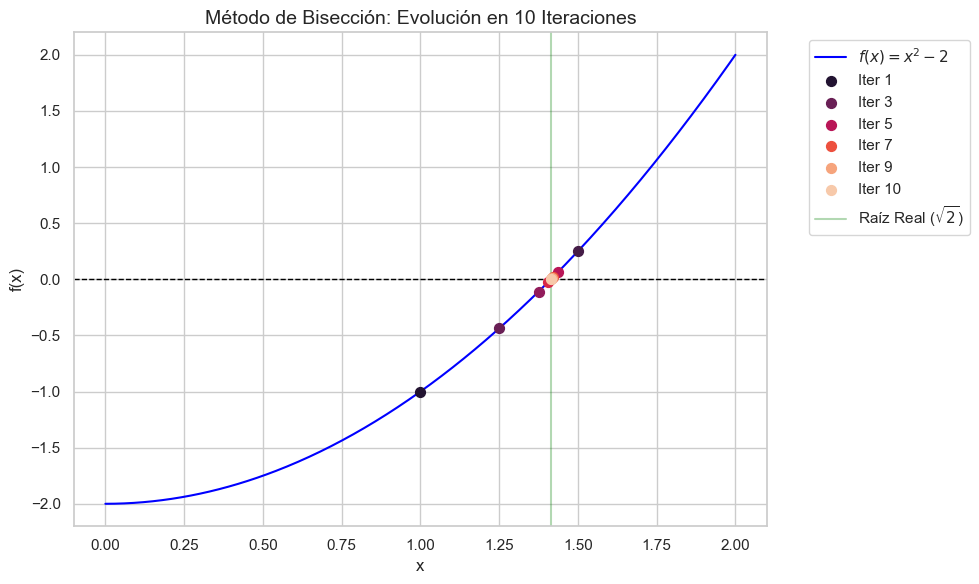

In [6]:

# 4. Representación Visual con Matplotlib y Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Dibujar la función f(x)
x_vals = np.linspace(0, 2, 400)
y_vals = f(x_vals)
sns.lineplot(x=x_vals, y=y_vals, color='blue', label='$f(x) = x^2 - 2$')

# Línea base en y=0
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Graficar la evolución de los puntos medios
colores = sns.color_palette("rocket", iteraciones)
for i, punto in enumerate(historial_m):
    plt.scatter(punto, f(punto), color=colores[i], s=50, zorder=3, 
                label=f'Iter {i+1}' if i % 2 == 0 or i == 9 else "")

# Marcar la raíz real
plt.axvline(np.sqrt(2), color='green', alpha=0.3, label='Raíz Real ($\sqrt{2}$)')

plt.title(f"Método de Bisección: Evolución en {iteraciones} Iteraciones", fontsize=14)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\biseccion_evolucion.png", dpi=300)
plt.show()



## Análisis del Algoritmo

El método de bisección funciona reduciendo el error a la mitad en cada paso. Matemáticamente, el error máximo después de $n$ iteraciones en un intervalo $[a, b]$ está dado por:

$$\text{Error} \leq \frac{b - a}{2^n}$$





En tu caso, con $a=0, b=2$ y $n=10$:
* **Error inicial:** $2$
* **Error final:** $\frac{2}{2^{10}} = \frac{2}{1024} \approx 0.00195$

Como puedes observar en la consola al ejecutar el código, el valor de $m$ se estabiliza rápidamente alrededor de **1.41**, que es la aproximación de $\sqrt{2}$. La gráfica de Seaborn muestra cómo los puntos (desde colores oscuros a claros) se deslizan por la curva hasta "atrapar" el punto donde la función cruza el eje horizontal.